# 5장 2강: 검정력 분석과 MDE 기반 표본 크기 산정 — 실습문제

## 실습 목표

- 기준 유지율과 MDE를 효과 크기로 변환하여 그룹당 필요 표본을 계산합니다.
- 유의수준, 검정력, MDE, 표본 크기의 관계를 설명합니다.
- MDE 변화에 따른 필요 표본과 예상 실험 기간을 비교합니다.
- 실제 트래픽과 운영 기간을 반영해 실험 설계의 실행 가능성을 판단합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, statsmodels, Matplotlib
- `cookie_cats.csv`
- 핵심 지표: `retention_7`
- 대조군: `gate_30`, 실험군: `gate_40`
- 양측검정, 유의수준 $\alpha=0.05$, 목표 검정력 0.80, 1:1 배정을 기본 조건으로 사용합니다.

> 현재 데이터의 `gate_30` 7일 유지율을 기준선의 **학습용 대리값**으로 사용합니다. 실제 신규 실험에서는 실험 결과가 아닌 과거 데이터나 사전 조사로 기준선을 정해야 합니다.

## 실습 준비

아래 셀을 실행하여 데이터와 분석 환경을 준비하세요.


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from statsmodels.stats.power import NormalIndPower
    from statsmodels.stats.proportion import proportion_effectsize
except ModuleNotFoundError:
    # statsmodels가 없는 최소 실행 환경을 위한 동일 공식의 대체 구현
    from scipy.stats import norm
    from scipy.optimize import brentq

    def proportion_effectsize(prop1, prop2):
        return 2 * np.arcsin(np.sqrt(prop1)) - 2 * np.arcsin(np.sqrt(prop2))

    class NormalIndPower:
        def solve_power(self, effect_size, nobs1=None, alpha=0.05, power=0.80,
                        ratio=1.0, alternative="two-sided"):
            if nobs1 is not None:
                raise NotImplementedError("이 노트북의 대체 구현은 표본 크기 계산만 지원합니다.")
            if alternative != "two-sided" or ratio != 1.0:
                raise NotImplementedError("양측검정과 1:1 배정만 지원합니다.")
            def achieved_power(sample1):
                sample2 = sample1 * ratio
                effective_n = 1 / (1 / sample1 + 1 / sample2)
                shift = effect_size * np.sqrt(effective_n)
                upper = norm.sf(norm.isf(alpha / 2) - shift)
                lower = norm.cdf(norm.ppf(alpha / 2) - shift)
                return upper + lower

            return brentq(lambda n: achieved_power(n) - power, 2, 1e9)

data_candidates = [Path("cookie_cats.csv"), Path("upload/cookie_cats.csv")]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("cookie_cats.csv 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05
target_power = 0.80

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("버전별 사용자 수:")
print(df["version"].value_counts().reindex(["gate_30", "gate_40"]))


데이터 크기: 90189행, 5열
전체 결측치 수: 0
버전별 사용자 수:
version
gate_30    44700
gate_40    45489
Name: count, dtype: int64


---

## 필수 1. 7일 유지율의 절대 1%p 증가를 탐지할 표본 크기 계산

`gate_30`의 관측 7일 유지율을 기준선으로 사용하여, 유지율이 절대 1%p 증가하는 효과를 탐지할 표본 크기를 계산하세요.

### 수행 요구사항

1. `gate_30`의 `retention_7` 평균을 기준 유지율로 계산하세요.
2. MDE를 `0.01`로 설정하고 목표 유지율을 계산하세요.
3. `proportion_effectsize()`로 효과 크기를 구하세요.
4. `NormalIndPower().solve_power()`로 그룹당 필요 표본을 계산하세요.
5. 표본 수는 소수점 이하를 올림하고, 전체 필요 표본도 계산하세요.
6. 현재 데이터의 두 그룹 중 더 작은 표본 수와 비교하세요.

### 질문

- 검정력 0.80은 무엇을 의미하나요?
-> 실제 비율이 설계에서 가정한 기준 비율과 목표 비율일 때, 같은 조건의 실험을 반복하면 약 80%가 통계적으로 유의한 차이를 탐지한다.

- MDE 1%p는 상대적으로 1% 증가한다는 뜻인가요?
-> 아닙니다. 약 19.02%에서 약 20.02%로 변하는 절대 1퍼센트 포인트 차이

- 계산된 표본을 반올림하지 않고 올림해야 하는 이유는 무엇인가요?
-> 
- 현재 데이터는 수치상 필요한 표본을 충족하나요?


In [3]:
# 여기에 코드를 작성하세요.

import math
import pandas as pd
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

df = pd.read_csv("cookie_cats.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# 1. gate_30의 기준 유지율
p1 = df.loc[df["version"] == "gate_30", "retention_7"].mean()

# 2. MDE 0.01 적용한 목표 유지율
mde = 0.01
p2 = p1 + mde

# 3. 효과 크기 (Cohen's h)
effect_size = proportion_effectsize(p2, p1)

# 4. 그룹당 필요 표본 (양측, alpha=0.05, power=0.80, ratio=1)
alpha, power = 0.05, 0.80
n_per_group = NormalIndPower().solve_power(
    effect_size=effect_size, alpha=alpha, power=power, ratio=1, alternative="two-sided"
)

# 5. 올림 처리 및 전체 필요 표본
n_per_group_ceil = math.ceil(n_per_group)
n_total = n_per_group_ceil * 2

print(f"기준 유지율(gate_30) : {p1:.4f}")
print(f"목표 유지율(+{mde})   : {p2:.4f}")
print(f"효과 크기(Cohen's h) : {effect_size:.6f}")
print(f"alpha={alpha}, power={power}, 양측검정")
print(f"그룹당 필요 표본      : {n_per_group:.2f} -> {n_per_group_ceil:,}명")
print(f"전체 필요 표본        : {n_total:,}명")

# 6. 현재 데이터의 더 작은 그룹과 비교
group_n = df["version"].value_counts()
min_name, min_n = group_n.idxmin(), group_n.min()
print(f"\n현재 그룹별 표본: {group_n.to_dict()}")
print(f"더 작은 그룹: {min_name} ({min_n:,}명)")
print(f"필요 표본 대비 여유: {min_n - n_per_group_ceil:+,}명 (배율 {min_n / n_per_group_ceil:.2f})")
print("판정:", "충분함" if min_n >= n_per_group_ceil else "부족함")

기준 유지율(gate_30) : 0.1902
목표 유지율(+0.01)   : 0.2002
효과 크기(Cohen's h) : 0.025232
alpha=0.05, power=0.8, 양측검정
그룹당 필요 표본      : 24657.14 -> 24,658명
전체 필요 표본        : 49,316명

현재 그룹별 표본: {'gate_40': 45489, 'gate_30': 44700}
더 작은 그룹: gate_30 (44,700명)
필요 표본 대비 여유: +20,042명 (배율 1.81)
판정: 충분함


---

## 필수 2. MDE별 표본 크기와 실험 기간 비교

MDE를 `0.5%p`, `1.0%p`, `1.5%p`, `2.0%p`로 바꾸어 필요한 표본과 기간을 비교하세요. 하루 전체 실험 대상 트래픽은 6,000명이고 A/B에 절반씩 배정한다고 가정합니다.

### 수행 요구사항

1. 각 MDE의 효과 크기와 그룹당 필요 표본을 계산하세요.
2. 전체 필요 표본과 예상 실험 일수를 계산하세요.
3. 계산 결과를 DataFrame으로 정리하세요.
4. MDE별 그룹당 필요 표본을 막대그래프로 나타내세요.
5. 최대 운영 가능 기간이 14일일 때 각 설계의 실행 가능 여부를 표시하세요.

### 질문

- MDE가 작아질수록 표본 크기와 기간은 어떻게 변하나요?
- 네 가지 설계 중 14일 안에 완료할 수 없는 것은 무엇인가요?
- 표본을 줄이기 위해 MDE를 무조건 크게 설정해도 되나요?
- MDE는 어떤 근거로 정해야 하나요?


기준 유지율(gate_30) = 0.1902 / 일 트래픽 6,000명 (그룹당 3,000명)

 MDE(%p)  목표유지율  효과크기(h)  그룹당표본   전체표본  예상일수 14일내가능
     0.5 0.1952 0.012677  97679 195358    33      X
     1.0 0.2002 0.025232  24658  49316     9      O
     1.5 0.2052 0.037669  11063  22126     4      O
     2.0 0.2102 0.049995   6281  12562     3      O

현재 백엔드: inline


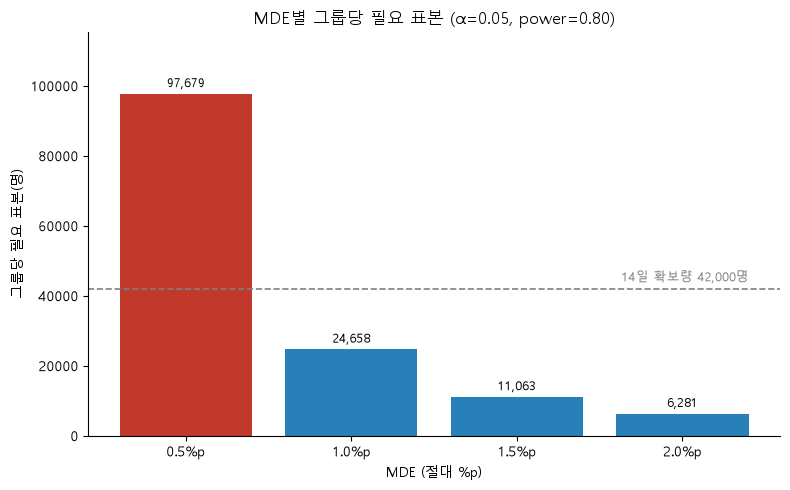

In [14]:


%matplotlib inline

import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

# 한글 폰트 설정
_cands = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]
_avail = {f.name for f in fm.fontManager.ttflist}
plt.rcParams["font.family"] = next((c for c in _cands if c in _avail), "DejaVu Sans")
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("Cookie_cats.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

p1 = df.loc[df["version"] == "gate_30", "retention_7"].mean()  # 기준 유지율
DAILY_TRAFFIC = 6000   # 하루 전체 실험 대상
DAILY_PER_GROUP = DAILY_TRAFFIC / 2
MAX_DAYS = 14
alpha, power = 0.05, 0.80

rows = []
for mde in [0.005, 0.010, 0.015, 0.020]:
    p2 = p1 + mde
    es = proportion_effectsize(p2, p1)                         # 1. 효과 크기
    n_grp = math.ceil(NormalIndPower().solve_power(
        effect_size=es, alpha=alpha, power=power, ratio=1, alternative="two-sided"))
    n_total = n_grp * 2                                        # 2. 전체 표본
    days = math.ceil(n_total / DAILY_TRAFFIC)                  #    예상 일수
    rows.append({
        "MDE(%p)": round(mde * 100, 1),
        "목표유지율": round(p2, 4),
        "효과크기(h)": round(es, 6),
        "그룹당표본": n_grp,
        "전체표본": n_total,
        "예상일수": days,
        "14일내가능": "O" if days <= MAX_DAYS else "X",         # 5. 실행 가능 여부
    })

result = pd.DataFrame(rows)                                    # 3. DataFrame 정리
print(f"기준 유지율(gate_30) = {p1:.4f} / 일 트래픽 {DAILY_TRAFFIC:,}명 (그룹당 {DAILY_PER_GROUP:,.0f}명)\n")
print(result.to_string(index=False))
print("\n현재 백엔드:", plt.get_backend())   # module://matplotlib_inline... 이면 정상

# 4. MDE별 그룹당 필요 표본 막대그래프
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#c0392b" if v == "X" else "#2980b9" for v in result["14일내가능"]]
bars = ax.bar(result["MDE(%p)"].astype(str) + "%p", result["그룹당표본"], color=colors)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
# 14일 운영 시 확보 가능한 그룹당 표본선
ax.axhline(DAILY_PER_GROUP * MAX_DAYS, color="gray", ls="--", lw=1.2)
ax.text(3.4, DAILY_PER_GROUP * MAX_DAYS * 1.05,
        f"14일 확보량 {DAILY_PER_GROUP*MAX_DAYS:,.0f}명", ha="right", color="gray", fontsize=9)
ax.set_title("MDE별 그룹당 필요 표본 (α=0.05, power=0.80)")
ax.set_xlabel("MDE (절대 %p)"); ax.set_ylabel("그룹당 필요 표본(명)")
ax.set_ylim(0, result["그룹당표본"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---

## 과제. 운영 제약을 반영한 Cookie Cats 표본 설계

다음 운영 조건에서 MDE 후보 `1.0%p`와 `1.5%p`를 비교하고 실행안을 선택하세요.

### 운영 조건

- 기준 7일 유지율: `gate_30` 관측값
- 유의수준: 0.05
- 목표 검정력: 0.80
- 양측검정, 1:1 배정
- 하루 전체 실험 대상 사용자: 5,000명
- 최대 모집 기간: 7일
- 데이터 누락·이탈 대비 여유 표본: 10%
- 비즈니스적으로 의미 있는 최소 변화: 1.5%p
- 최대 모집 기간 7일은 실험 참여자를 모집하는 기간입니다. 모든 참여자의 7일 유지율을 확인하려면 마지막 참여자 모집 후 추가로 7일의 관찰 기간이 필요합니다.

### 수행 요구사항

1. 두 MDE 후보의 기본 그룹당 표본을 계산하세요.
2. 기본 표본을 `0.90`으로 나누어 10% 누락을 고려한 그룹당 모집 목표를 계산하고 올림하세요.
3. 전체 모집 목표와 예상 모집 기간을 계산하세요.
4. 7일 안에 목표 표본 모집이 가능한지 판단하세요.
5. 아래 질문을 포함하여 5~7문장의 최종 결론을 작성하세요.

### 질문

- 어떤 MDE 설계를 선택해야 하나요?
-> MDE 1.5%p 설계를 선택.

- 선택한 설계가 통계적 조건과 비즈니스 기준을 모두 만족하나요?
-> 두 조건 모두 만족한다. 

- 선택하지 않은 설계는 왜 현재 운영 조건에 맞지 않나요?
-> 표본 확보가 물리적으로 불가능하고, 그에 따른 연쇄적 비용이 발생하기 때문이다.

- 실제 실행 전에 추가로 확인해야 할 사항은 무엇인가요?
-> 하루 5,000명이라는 유입 가정의 안정성, 모집 기간을 5일이 아닌 7일로 채울 것인가, 단측 검정인지 양측 검정인지

> 과제는 필수 문제와 동일한 수준이며, 제시된 조건을 같은 계산 절차에 적용하면 됩니다.


In [16]:
# 여기에 코드를 작성하세요.
import math
import pandas as pd
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

df = pd.read_csv("cookie_cats.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

p1 = df.loc[df["version"] == "gate_30", "retention_7"].mean()  # 기준 7일 유지율

ALPHA, POWER = 0.05, 0.80
DAILY_TRAFFIC = 5000        # 하루 전체 실험 대상
MAX_RECRUIT_DAYS = 7        # 최대 모집 기간
OBSERVE_DAYS = 7            # 마지막 참여자 관찰 기간
BUFFER = 0.90               # 10% 누락 대비 (표본 / 0.90)
BUSINESS_MDE = 0.015        # 비즈니스적으로 의미 있는 최소 변화

rows = []
for mde in [0.010, 0.015]:
    p2 = p1 + mde
    es = proportion_effectsize(p2, p1)
    # 1. 기본 그룹당 표본
    n_base = math.ceil(NormalIndPower().solve_power(
        effect_size=es, alpha=ALPHA, power=POWER, ratio=1, alternative="two-sided"))
    # 2. 10% 누락 반영 모집 목표
    n_recruit = math.ceil(n_base / BUFFER)
    # 3. 전체 모집 목표 및 예상 모집 기간
    n_total = n_recruit * 2
    recruit_days = math.ceil(n_total / DAILY_TRAFFIC)
    rows.append({
        "MDE(%p)": round(mde * 100, 1),
        "목표유지율": round(p2, 4),
        "효과크기(h)": round(es, 6),
        "기본_그룹당": n_base,
        "모집목표_그룹당": n_recruit,
        "전체모집목표": n_total,
        "모집일수": recruit_days,
        # 4. 7일 내 모집 가능 여부
        "7일내모집": "가능" if recruit_days <= MAX_RECRUIT_DAYS else "불가",
        "총소요일수": recruit_days + OBSERVE_DAYS,   # 모집 + 관찰
    })

result = pd.DataFrame(rows)
cap_total = DAILY_TRAFFIC * MAX_RECRUIT_DAYS
print(f"기준 유지율(gate_30) = {p1:.4f}")
print(f"하루 {DAILY_TRAFFIC:,}명 / 7일 최대 모집량 = {cap_total:,}명 (그룹당 {cap_total//2:,}명)\n")
print(result.to_string(index=False))

print("\n[판단]")
for r in rows:
    gap = r["전체모집목표"] - cap_total
    print(f"MDE {r['MDE(%p)']}%p : 필요 {r['전체모집목표']:,}명 vs 7일 확보 {cap_total:,}명 "
          f"-> {gap:+,}명 ({r['7일내모집']}), 총 {r['총소요일수']}일 소요")


기준 유지율(gate_30) = 0.1902
하루 5,000명 / 7일 최대 모집량 = 35,000명 (그룹당 17,500명)

 MDE(%p)  목표유지율  효과크기(h)  기본_그룹당  모집목표_그룹당  전체모집목표  모집일수 7일내모집  총소요일수
     1.0 0.2002 0.025232   24658     27398   54796    11    불가     18
     1.5 0.2052 0.037669   11063     12293   24586     5    가능     12

[판단]
MDE 1.0%p : 필요 54,796명 vs 7일 확보 35,000명 -> +19,796명 (불가), 총 18일 소요
MDE 1.5%p : 필요 24,586명 vs 7일 확보 35,000명 -> -10,414명 (가능), 총 12일 소요


---

## 실습 마무리

- 어떤 문제가 있었는가?
-> 표본을 감으로 정하면 효과 크기를 제대로 알기 어렵고 필요 이상으로 긴 시범운영을 운영할 수가 있다.
-> MDE를 적게 설정해도 실제 트래픽을 고려하여 표본을 모을 수 없다면 실행 가능한 설계는 될 수 없다.

- 어떻게 개선했는가?
-> 기준 유지율, MDE, 유의수준, 검정력을 사용해 그룹당 표본을 계간하고 실제 트래픽과 모집 기간을 반영했다.

- 무엇을 근거로 개선되었다고 판단했는가?
-> MDE 0.5 ~ 2.0까지 표본과 기간을 수치로 비교하여 확인했다. 

표본 크기를 감으로 정했을 때의 문제와, 기준선·MDE·검정력·트래픽·운영 기간을 연결하면서 설계가 어떻게 개선되었는지 정리하세요.
